### MVP for LinkBikeNet

In [1]:
# imports
import os
import osmnx as ox
import networkx as nx
import pandas as pd

from linkbikenet.functions import *

In [2]:
# config
city_name = 'Tirana'
ox.settings.useful_tags_way = ["highway", "cycleway", "cycleway:right", "cycleway:left", "cycleway:both", "cyclestreet"]
import_files={'bike_network':"./tirana_al.gpkg"}
proj_crs="3857"

In [3]:
h = import_bike_network(import_files['bike_network'])
h = ox.project_graph(h, to_crs=proj_crs)
h = nx.Graph(h)

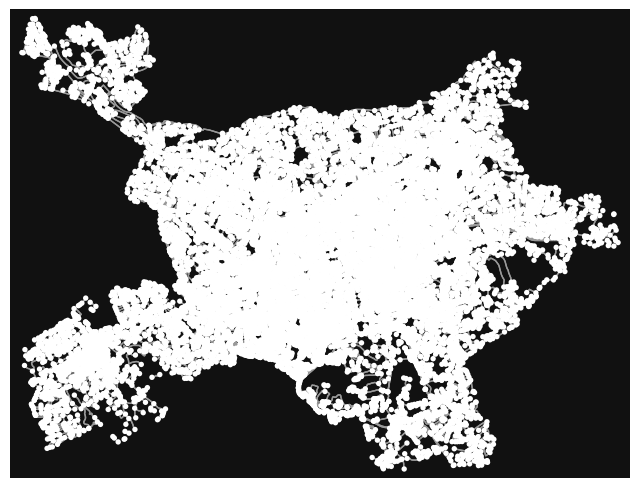

In [4]:
# fetch street network from OSM
g = ox.graph_from_place(
        city_name, network_type='all_public', simplify=False, retain_all=True
    )
g = ox.simplify_graph(
    g,
    edge_attrs_differ=['cycleway', 'highway', 'cycleway:right', 'cycleway:left', 'cycleway:both'],
)
ox.plot_graph(g);

In [5]:
g = ox.project_graph(g, to_crs="3857")

### Tag edges that have protected bicycle infrastructure

In [6]:
g = map_edges_to_bike_infrastructure(g)

### Drop parallel edges and convert to undirected graph

In [7]:
# finding parallel edges and dropping them
edges_to_drop = find_edges_to_drop(g)
g.remove_edges_from(edges_to_drop)

In [8]:
# Capital-G: the Graph() object we will be working with from now on
G = nx.Graph(g)

### Build graph with all protected infrastructure

In [9]:
edges = [
    (u, v)
    for u, v, data in G.edges(data=True)
    if data.get("pbi") == 1
]

if import_files['bike_network'] is not None:
    H = h.copy()
else:
    H = G.edge_subgraph(edges).copy()

In [10]:
wcc = [H.subgraph(c).copy() for c in sorted(nx.connected_components(H), key=lambda c: sum([l[-1] for l in H.subgraph(c).copy().edges.data('length')]), reverse=True)]

In [11]:
# Nodes belonging to the original largest component
main_component = set(wcc[0])

# Mark all edges in the original largest component as step 0
for u, v in H.subgraph(main_component).edges():
    H[u][v]["lcc_step"] = 0

In [12]:
to_iterate = len(wcc) -1
closest_pairs = []
step = 1
for i in range(to_iterate):
    wcc = [H.subgraph(c).copy() for c in sorted(nx.connected_components(H), key=lambda c: sum(
        [l[-1] for l in H.subgraph(c).copy().edges.data('length')]), reverse=True)]
    pair = pair_between_largest_components(wcc)
    # Determine which components contain u and v
    component_u = next(c for c in wcc if pair[0] in c)
    component_v = next(c for c in wcc if pair[1] in c)
    u_in_main = pair[0] in main_component
    v_in_main = pair[1] in main_component
    closest_pairs.append(pair)
    H.add_edge(pair[0], pair[1], length=0, lcc_step=None)
    if u_in_main and not v_in_main:
        mark_joined_component(H, component_v, step)
        main_component.update(component_v)
        H[pair[0]][pair[1]]["lcc_step"] = step

    elif v_in_main and not u_in_main:
        mark_joined_component(H, component_u, step)
        main_component.update(component_u)
        H[pair[0]][pair[1]]["lcc_step"] = step
    step += 1

In [13]:
# find paths between nodes
paths = []
for pair in closest_pairs:
    try:
        path = nx.shortest_path(G, pair[0], pair[1], weight='length')
    except nx.NetworkXNoPath:
        continue
    paths.append(path)

In [28]:
H.remove_edges_from(closest_pairs)
edges_pbi_gdf = graph_edges_to_gdf(H)
edges_gdf = graph_edges_to_gdf(G)

In [42]:
edges_pbi_gdf.set_crs(epsg=4326, allow_override=True, inplace=True)

access bridge footway        highway junction lanes  \
u           v                                                                 
15493021    4652332064                         living_street                  
            15461424                           living_street                  
            1843574832                         living_street                  
4652332064  1458037101                         living_street                  
            4652332059                              cycleway                  
...                        ...    ...     ...            ...      ...   ...   
12104386197 12103394999                             cycleway                  
12103420503 12104395903                             cycleway                  
6297599068  6297599071                         living_street                  
12141005253 12141005257                        living_street                  
10922895977 12173793268                             cycleway                  

                        maxspeed                 name oneway segregated  \
u           v                                                             
15493021    4652332064               Rruga Mihal Popi    yes              
            15461424              Rruga Mustafa Qosja    yes              
            1843574832            Rruga Mustafa Qosja    yes              
4652332064  1458037101               Rruga Mihal Popi    yes              
            4652332059                                    no              
...                          ...                  ...    ...        ...   
12104386197 12103394999                                                   
12103420503 12104395903                                                   
6297599068  6297599071                                                    
12141005253 12141005257                                                   
10922895977 12173793268                                                   

                        tunnel cycleway:left cycleway:right       osmid  \
u           v                                                             
15493021    4652332064                                          3192445   
            15461424                                            4042247   
            1843574832                                          4042247   
4652332064  1458037101                                          3192445   
            4652332059                                        671530085   
...                        ...           ...            ...         ...   
12104386197 12103394999                                      1306941968   
12103420503 12104395903                                      1306941972   
6297599068  6297599071                                       1311637408   
12141005253 12141005257                                      1311637413   
10922895977 12173793268                                      1315213296   

                          length         from           to  \
u           v                                                
15493021    4652332064    28.314     15493021   4652332064   
            15461424      34.144     15493021     15461424   
            1843574832    38.110     15493021   1843574832   
4652332064  1458037101     4.088   4652332064   1458037101   
            4652332059    92.609   4652332064   4652332059   
...                          ...          ...          ...   
12104386197 12103394999  532.202  12104386197  12103394999   
12103420503 12104395903  558.401  12103420503  12104395903   
6297599068  6297599071   123.407   6297599068   6297599071   
12141005253 12141005257   46.905  12141005253  12141005257   
10922895977 12173793268  259.784  10922895977  12173793268   

                                                                  geometry  \
u           v                                                                
15493021    4652332064    LINESTRING (19.8069 41.32001, 19.80672 41.31979)   
   

In [26]:
edges_pbi_gdf.to_crs(epsg=4326, inplace=True)

In [44]:
edges_pbi_gdf.to_file("test_tirana_existing_network", driver="GeoJSON", RFC7946="YES")

In [ ]:
df = pd.DataFrame()
df['nodelist'] = paths

In [ ]:
df['edge_list'] = df.nodelist.apply(lambda x: get_correct_edgetuples(edges_gdf, x))

In [ ]:
gdf = create_gdf_with_geoms(df, edges_gdf)

In [ ]:
len(gdf)

In [ ]:
# reset Graph
H = G.edge_subgraph(edges).copy()

# calculating connectivity metrics
print("Calculating connectivity metrics...")
network_lengths = []
lcc_lengths = []
edge_lengths = gdf['geometry'].length

for i in range(len(gdf)):
    H.add_edge(closest_pairs[i][0], closest_pairs[i][1], length=edge_lengths[i])
    total, largest = calculate_network_statistics(H)
    network_lengths.append(total)
    lcc_lengths.append(largest)

In [ ]:
gdf['network_length'] = network_lengths
gdf['lcc_length'] = lcc_lengths

In [ ]:
os.makedirs("./results/", exist_ok=True)
gdf.geometry = gdf.geometry.set_precision(grid_size=1)
gdf.to_file("./results/budapest.geojson", driver="GeoJSON")

In [ ]:
edges_pbi_gdf = edges_gdf[edges_gdf["pbi"] == 1]

In [ ]:
edges_pbi_gdf.geometry = edges_pbi_gdf.geometry.set_precision(grid_size=1)
edges_pbi_gdf.to_file("./results/Budapest_bike_network.geojson", driver="GeoJSON")